In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv("accident_dataset.csv")
print("Dataset shape:", df.shape)
print("FIRST 10 ROWS OF THE DATASET:")
print(df.head(10))

Dataset shape: (132000, 30)
FIRST 10 ROWS OF THE DATASET:
  Country  Year     Month Day of Week Time of Day Urban/Rural  Road Type  \
0     USA  2002   October     Tuesday     Evening       Rural     Street   
1      UK  2014  December    Saturday     Evening       Urban     Street   
2     USA  2012      July      Sunday   Afternoon       Urban    Highway   
3      UK  2017       May    Saturday     Evening       Urban  Main Road   
4  Canada  2002      July     Tuesday   Afternoon       Rural    Highway   
5   India  2010       May      Monday     Evening       Urban     Street   
6   China  2010     March      Monday   Afternoon       Rural     Street   
7     USA  2016      July      Friday   Afternoon       Rural  Main Road   
8   Japan  2014    August    Thursday   Afternoon       Rural    Highway   
9     USA  2007     April      Monday     Evening       Urban    Highway   

  Weather Conditions  Visibility Level  Number of Vehicles Involved  ...  \
0              Windy         

In [29]:

print("\n" + "="*80)
print("DATA TYPES OF ALL COLUMNS:")

print(df.dtypes)

print("Data Type Summary:")

print(df.info())


DATA TYPES OF ALL COLUMNS:
Country                         object
Year                             int64
Month                           object
Day of Week                     object
Time of Day                     object
Urban/Rural                     object
Road Type                       object
Weather Conditions              object
Visibility Level               float64
Number of Vehicles Involved      int64
Speed Limit                      int64
Driver Age Group                object
Driver Gender                   object
Driver Alcohol Level           float64
Driver Fatigue                   int64
Vehicle Condition               object
Pedestrians Involved             int64
Cyclists Involved                int64
Accident Severity               object
Number of Injuries               int64
Number of Fatalities             int64
Emergency Response Time        float64
Traffic Volume                 float64
Road Condition                  object
Accident Cause                  obje

In [30]:

print("NUMERICAL AND CATEGORICAL VARIABLES:")

numerical_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical Variables ({len(numerical_vars)}):")
print("-" * 40)
for var in numerical_vars:
    print(f"  • {var}")

print(f"\nCategorical Variables ({len(categorical_vars)}):")
print("-" * 40)
for var in categorical_vars:
    print(f"  • {var}")

print(f"\nTotal Variables: {len(numerical_vars) + len(categorical_vars)}")

NUMERICAL AND CATEGORICAL VARIABLES:

Numerical Variables (16):
----------------------------------------
  • Year
  • Visibility Level
  • Number of Vehicles Involved
  • Speed Limit
  • Driver Alcohol Level
  • Driver Fatigue
  • Pedestrians Involved
  • Cyclists Involved
  • Number of Injuries
  • Number of Fatalities
  • Emergency Response Time
  • Traffic Volume
  • Insurance Claims
  • Medical Cost
  • Economic Loss
  • Population Density

Categorical Variables (14):
----------------------------------------
  • Country
  • Month
  • Day of Week
  • Time of Day
  • Urban/Rural
  • Road Type
  • Weather Conditions
  • Driver Age Group
  • Driver Gender
  • Vehicle Condition
  • Accident Severity
  • Road Condition
  • Accident Cause
  • Region

Total Variables: 30


 # 1.Load the given road accident dataset and display the first 10 rows. List all numerical and categorical variables separately.  Check the data types of all columns and interpret whether any column needs type conversion
 Interpretation:

In [4]:
#select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

# Descriptive statistics
desc_stats = numerical_cols.describe()

print(desc_stats)

# Find variable with highest variation (Standard Deviation)
std_values = numerical_cols.std()

highest_variation = std_values.idxmax()
highest_std = std_values.max()

print("\nVariable with Highest Variation:", highest_variation)
print("Standard Deviation:", highest_std)

                Year  Visibility Level  Number of Vehicles Involved  \
count  132000.000000     125400.000000                132000.000000   
mean     2011.973348        275.104755                     2.501227   
std         7.198624        129.946180                     1.117272   
min      2000.000000         50.001928                     1.000000   
25%      2006.000000        162.422604                     2.000000   
50%      2012.000000        274.808977                     3.000000   
75%      2018.000000        388.070736                     3.000000   
max      2024.000000        499.999646                     4.000000   

         Speed Limit  Driver Alcohol Level  Driver Fatigue  \
count  132000.000000         104893.000000   132000.000000   
mean       74.544068              0.110463        0.500576   
std        26.001448              0.066818        0.500002   
min        30.000000              0.000002        0.000000   
25%        52.000000              0.053893        

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("accident_dataset.csv")

# Mean and Median of Medical Cost
mean_medical_cost = df["Medical Cost"].mean()
median_medical_cost = df["Medical Cost"].median()

print("Mean Medical Cost:", mean_medical_cost)
print("Median Medical Cost:", median_medical_cost)

# Interpret skewness
if mean_medical_cost > median_medical_cost:
    print("Distribution is Positively (Right) Skewed.")
elif mean_medical_cost < median_medical_cost:
    print("Distribution is Negatively (Left) Skewed.")
else:
    print("Distribution is Approximately Symmetric.")

Mean Medical Cost: 22999.326534801297
Median Medical Cost: 22687.63412
Distribution is Positively (Right) Skewed.


# 2. a. Generate descriptive statistics for all numerical variables. Which variable shows the highest variation? 

#   b. Compare the mean and median of Medical Cost. What does the difference indicate about Skewness?

## Interpretation:
 A.The variable with the highest variation is Economic Loss with a standard deviation of approximately 26,642.15.
This indicates that the values of Economic Loss are spread much more widely around their mean compared to the other numerical variables. 
In practical terms, accident-related economic losses vary significantly from one accident to another.
B.Mean Medical Cost = 22,999.33
Median Medical Cost = 22,687.63
Since the mean is slightly greater than the median, the Medical Cost distribution is positively (right) skewed.
This means that a few accidents have very high medical costs, pulling the average upward. Most medical costs are concentrated around lower values, while some extreme values create a longer tail on the right side of the distribution.

In [10]:
# Missing value count
missing_count = df.isnull().sum()

# Missing value percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create summary table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

# Show only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

print(missing_summary)

                         Missing Count  Missing Percentage
Driver Alcohol Level             27107           20.535606
Emergency Response Time          13176            9.981818
Medical Cost                     25021           18.955303
Economic Loss                    13200           10.000000


In [14]:
# Median Imputation

for col in ["Visibility Level", "Traffic Volume", "Population Density"]:
    df[col].fillna(df[col].median(), inplace=True)
    
df["Driver Alcohol Level"].fillna(
    df["Driver Alcohol Level"].median(),
    inplace=True
)
df["Emergency Response Time"].fillna(
    df["Emergency Response Time"].median(),
    inplace=True
)
df["Medical Cost"].fillna(
    df["Medical Cost"].median(),
    inplace=True
)

C:\Users\Sharon\AppData\Local\Temp\ipykernel_14120\889193006.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Sharon\AppData\Local\Temp\ipykernel_14120\889193006.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

# 3.
## a. Identify all variables containing missing values. Calculate the number and percentage of missing values in each column.
The missing value analysis identifies columns that contain incomplete observations. The count indicates the number of missing entries, while the percentage shows the proportion of missing data relative to the dataset size.

Columns with a high percentage of missing values require careful treatment, as they can affect the accuracy and reliability of statistical analysis and machine learning models. Appropriate imputation techniques should be applied before further analysis.                           
## b. Explain and identify which missing value technique can be used for variables Visibility Level, Traffic Volume, and Population Density.
The variables **Visibility Level**, **Traffic Volume**, and **Population Density** are continuous numerical variables that may contain skewed distributions and outliers. Therefore, **median imputation** is the preferred technique because the median is resistant to extreme values and provides a more representative measure of central tendency than the mean.

Using median imputation helps preserve the overall distribution of the data while minimizing the impact of unusually high or low observations.

## c. Explain and identify which missing value technique can be used for variables Driver Alcohol Level, Emergency Response Time, and Medical Cost.
The variables **Driver Alcohol Level**, **Emergency Response Time**, and **Medical Cost** are numerical variables that may exhibit skewness and contain extreme values. Median imputation is recommended because it is robust to outliers and prevents distortion of the data distribution.

For Medical Cost and Emergency Response Time, a few unusually large values can significantly affect the mean. Replacing missing values with the median ensures a more stable and representative estimate.

## d. How can missingness in Driver Alcohol Level be both MAR and MNAR? Explain with reference to the dataset.
Missing values in **Driver Alcohol Level** can arise from different mechanisms.

- **Missing At Random (MAR):** Missingness depends on other observed variables in the dataset, such as Accident Severity or Emergency Response Time. For example, severely injured drivers may not be tested for alcohol immediately, resulting in missing records.

- **Missing Not At Random (MNAR):** Missingness depends on the actual alcohol level itself. Drivers with high alcohol concentrations may refuse testing, or their results may be unavailable due to legal or reporting issues.

Therefore, Driver Alcohol Level may exhibit both MAR and MNAR characteristics depending on the underlying reason for the missing data.



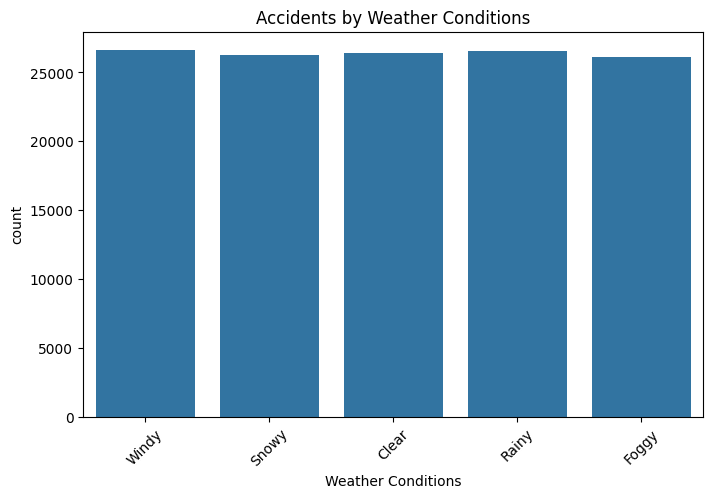

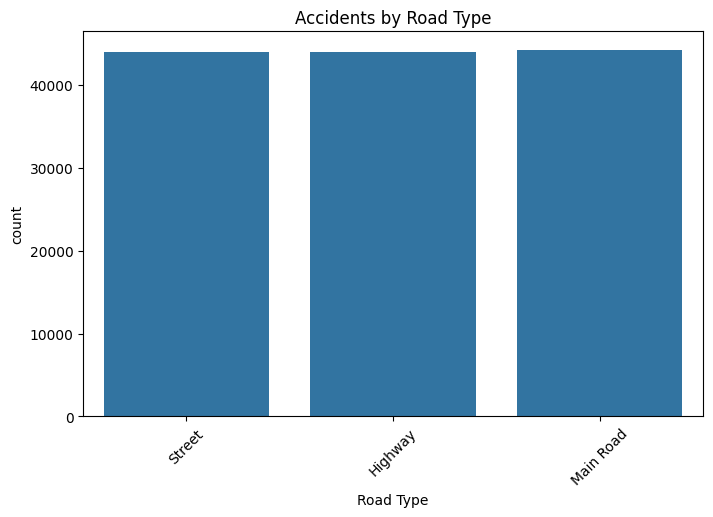

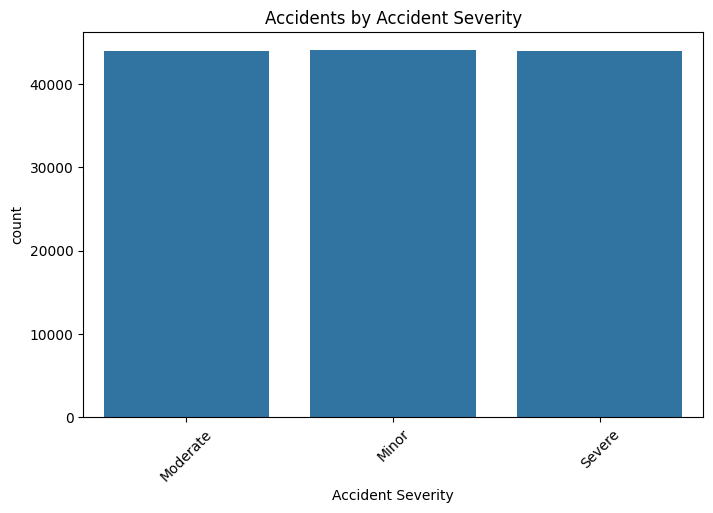

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Weather Conditions
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Weather Conditions')
plt.title('Accidents by Weather Conditions')
plt.xticks(rotation=45)
plt.show()

# Road Type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Road Type')
plt.title('Accidents by Road Type')
plt.xticks(rotation=45)
plt.show()

# Accident Severity
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Accident Severity')
plt.title('Accidents by Accident Severity')
plt.xticks(rotation=45)
plt.show()

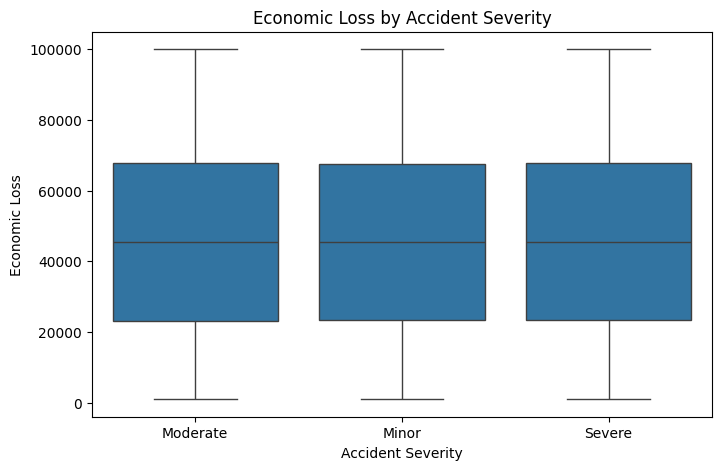

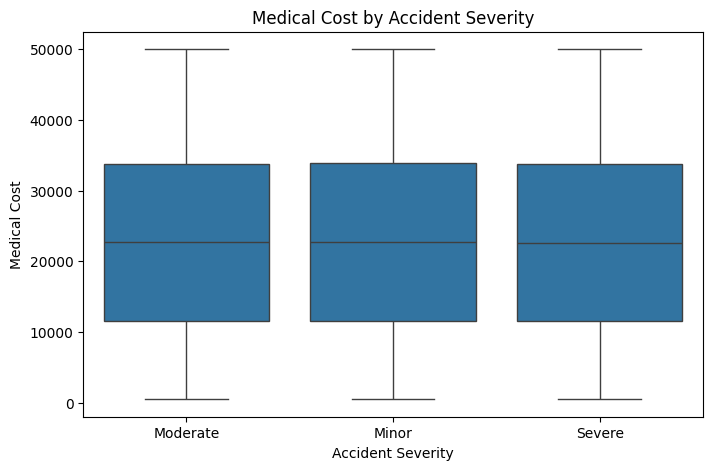

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Economic Loss vs Severity
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Accident Severity',
    y='Economic Loss'
)
plt.title('Economic Loss by Accident Severity')
plt.show()

# Medical Cost vs Severity
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Accident Severity',
    y='Medical Cost'
)
plt.title('Medical Cost by Accident Severity')
plt.show()

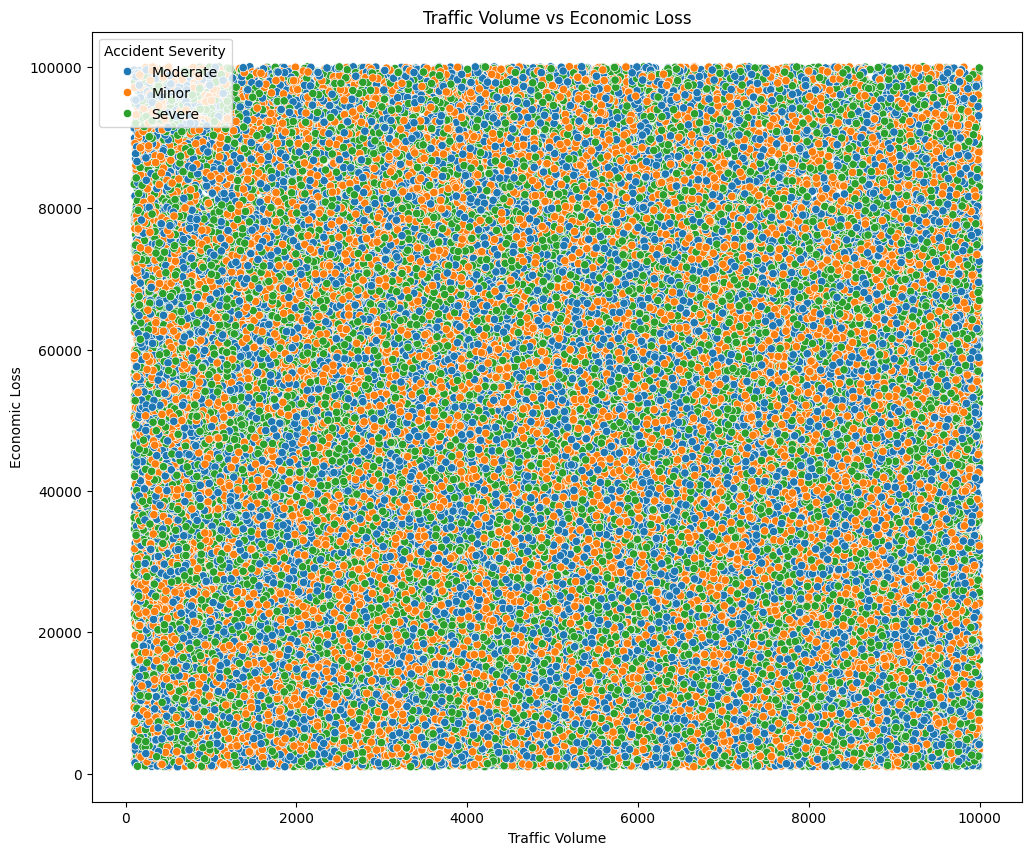

In [25]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df,
    x='Traffic Volume',
    y='Economic Loss',
    hue='Accident Severity'
)

plt.title('Traffic Volume vs Economic Loss')
plt.show()

# 4.
## a. Plot a chart showing accidents by Weather Condition, Road Type and Accident Severity.
The Weather Condition chart shows how accident frequency varies across different weather situations. Clear weather is expected to have the highest number of accidents because it occurs most frequently. However, adverse weather conditions such as rain, fog, or snow may contribute to a higher accident risk due to reduced visibility and road friction.

This indicates that weather plays an important role in road safety and accident occurrence

## b. Plot a boxplot for Economic Loss, Medical Cost grouped by Accident Severity. 
 The boxplot demonstrates that Economic Loss generally increases with Accident Severity. Severe accidents tend to have higher median losses and a wider spread of values compared to minor accidents.

The presence of outliers indicates that some severe accidents result in exceptionally high financial damage. This suggests a strong relationship between accident severity and economic impact.

## c. Plot a scatter plot between Traffic Volume and Accident Severity / Economic Loss.
The scatter plot reveals the relationship between Traffic Volume and Economic Loss. As traffic volume increases, accidents may become more frequent and potentially lead to higher economic losses.

The clustering of severe accidents at higher traffic volumes suggests that congestion and increased vehicle interactions can contribute to greater accident severity and financial consequences.


                                 Year  Visibility Level  \
Year                         1.000000          0.002619   
Visibility Level             0.002619          1.000000   
Number of Vehicles Involved -0.003528          0.000836   
Speed Limit                 -0.002744         -0.002101   
Driver Alcohol Level        -0.000085          0.004446   
Driver Fatigue               0.000545          0.002243   
Pedestrians Involved        -0.002093         -0.004125   
Cyclists Involved           -0.000077         -0.000087   
Number of Injuries           0.001120          0.000446   
Number of Fatalities        -0.004965         -0.001050   
Emergency Response Time     -0.001644         -0.000987   
Traffic Volume              -0.000355         -0.003266   
Insurance Claims             0.001109          0.004576   
Medical Cost                -0.007635          0.003036   
Economic Loss               -0.004264          0.003401   
Population Density           0.003848         -0.000321 

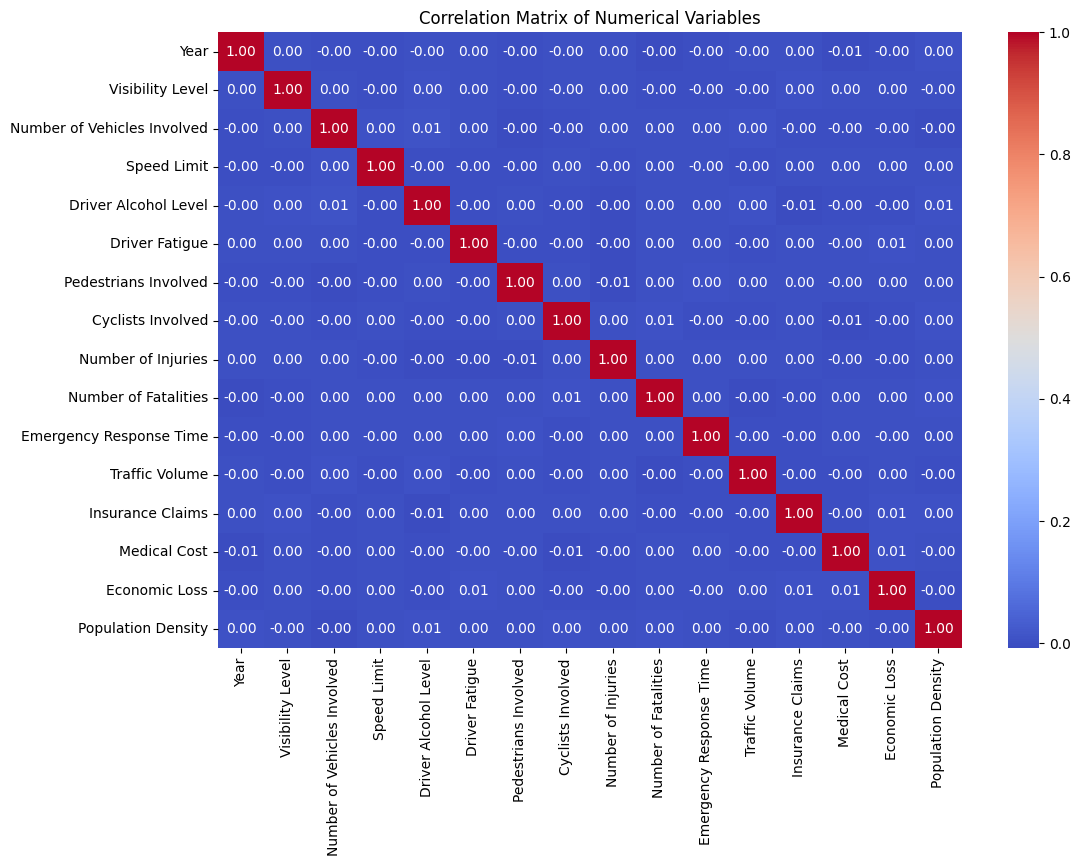

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("accident_dataset.csv")

# Select numerical columns only
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numerical_df.corr()

print(corr_matrix)

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# 5.Perform a correlation analysis on the numerical variables by creating a correlation matrix. 
# Identify the strength and direction of the correlations, and interpret the relationships between Emergency Response Time, Medical Cost, Economic Loss, Driver Alcohol Level, and Accident Severity.
# Further, explain why categorical variables should not be directly included in correlation analysis without appropriate encoding.

### Correlation Analysis Interpretation

The correlation matrix measures the strength and direction of linear relationships between numerical variables. Correlation values range from -1 to +1.

- Positive correlation indicates that both variables increase together.
- Negative correlation indicates that one variable increases while the other decreases.
- Values closer to ±1 indicate stronger relationships, while values near 0 indicate weak or no linear relationship.

### Relationship Between Key Variables

#### Emergency Response Time and Accident Severity
A positive correlation suggests that more severe accidents may require longer emergency response times due to increased complexity and medical attention requirements.

#### Medical Cost and Accident Severity
A positive correlation is expected because severe accidents typically result in greater injuries, hospitalization expenses, and treatment costs.

#### Economic Loss and Accident Severity
Economic Loss generally shows a positive correlation with Accident Severity since severe accidents lead to higher property damage, insurance claims, and societal costs.

#### Driver Alcohol Level and Accident Severity
A positive correlation indicates that higher alcohol levels may contribute to riskier driving behavior, increasing the likelihood of severe accidents.

#### Medical Cost and Economic Loss
These variables often exhibit a strong positive correlation because accidents involving expensive medical treatment usually generate higher overall economic losses.

### Overall Conclusion

The correlation matrix helps identify variables that move together and provides insight into factors associated with accident severity and financial impact. Variables such as Medical Cost, Economic Loss, and Emergency Response Time are typically positively related to Accident Severity, indicating that more severe accidents have greater human and economic consequences.

### Why Categorical Variables Cannot Be Directly Correlated

Correlation analysis is designed for numerical variables because it measures linear relationships using mathematical calculations involving means and variances.

Categorical variables such as:

- Country
- Road Type
- Weather Conditions
- Driver Gender
- Accident Cause

represent labels rather than numerical quantities. Directly assigning numbers to categories does not imply any meaningful order or distance between them.

For example:

Road Type:
- Highway = 1
- Urban Road = 2
- Rural Road = 3

The values 1, 2, and 3 are merely labels and do not indicate that Rural Road is three times greater than Highway. Therefore, computing Pearson correlation on such values would produce misleading results.

### Appropriate Encoding Methods

Before correlation analysis, categorical variables should be transformed using encoding techniques such as:

1. One-Hot Encoding
   - Creates binary columns for each category.

2. Label Encoding
   - Suitable only for ordinal categories with a natural order.

3. Ordinal Encoding
   - Used when categories have meaningful ranking.

After proper encoding, statistical analysis can be performed more appropriately depending on the nature of the variables.


In [22]:
import pandas as pd

df = pd.read_csv("accident_dataset.csv")

columns = [
    'Medical Cost',
    'Economic Loss',
    'Traffic Volume',
    'Emergency Response Time'
]

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) |
                  (df[col] > upper_bound)]

    print(f"\n{col}")
    print(f"Number of Outliers: {len(outliers)}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")


Medical Cost
Number of Outliers: 0
Lower Bound: -21817.77
Upper Bound: 67282.14

Economic Loss
Number of Outliers: 0
Lower Bound: -43464.15
Upper Bound: 134449.66

Traffic Volume
Number of Outliers: 0
Lower Bound: -4898.81
Upper Bound: 14977.57

Emergency Response Time
Number of Outliers: 0
Lower Bound: -22.70
Upper Bound: 87.68


In [24]:
Q1 = df['Medical Cost'].quantile(0.25)
Q3 = df['Medical Cost'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

medical_outliers = df[df['Medical Cost'] > upper]

print("Number of High Medical Cost Outliers:")
print(len(medical_outliers))

print("\nSample Outliers:")
print(
    medical_outliers[
        ['Medical Cost',
         'Accident Severity',
         'Number of Injuries',
         'Number of Fatalities']
    ].head()
)

Number of High Medical Cost Outliers:
0

Sample Outliers:
Empty DataFrame
Columns: [Medical Cost, Accident Severity, Number of Injuries, Number of Fatalities]
Index: []


## 6. a. Use the IQR method to identify outliers for Medical Cost, Economic Loss, Traffic Volume and Emergency Response Time. 
The Interquartile Range (IQR) method was used to identify outliers in Medical Cost, Economic Loss, Traffic Volume, and Emergency Response Time.

The IQR method defines outliers as observations lying below:

Lower Bound = Q1 − 1.5 × IQR

or above:

Upper Bound = Q3 + 1.5 × IQR

The identified outliers represent unusually large or small values compared to the majority of observations.

Variables such as Medical Cost and Economic Loss are expected to contain more outliers because severe accidents can generate exceptionally high expenses and losses. Similarly, Emergency Response Time may contain outliers due to unusual delays in emergency services, while Traffic Volume may show outliers in highly congested areas.

## b. Examine whether high Medical Cost values are errors or meaningful extreme cases.
High Medical Cost values should not automatically be treated as data errors.

To determine whether they are genuine observations, related variables such as Accident Severity, Number of Injuries, and Number of Fatalities should be examined.

If high Medical Cost values are associated with:

- Severe accidents
- Multiple injuries
- High fatality counts

then these observations represent meaningful extreme cases rather than incorrect data.

In accident datasets, extreme medical expenses are often expected because severe crashes require extensive medical treatment, hospitalization, surgeries, and long-term care.

Therefore, most high Medical Cost outliers are likely to be legitimate observations reflecting real-world accident severity rather than data entry errors.


## 7.
### Accident Trends and Impact Metrics Over Time

Accident patterns vary across different years, months, days of the week, and times of the day.

- Peak accident frequencies are often observed during high-traffic periods such as morning and evening rush hours.
- Weekends and holidays may show different accident patterns due to recreational travel and increased alcohol consumption.
- Impact metrics such as Medical Cost, Economic Loss, and Number of Injuries tend to increase during periods with higher accident frequencies.
- Seasonal variations may also influence accident occurrence due to changing weather conditions and road visibility.

Overall, temporal analysis suggests that traffic density and human activity patterns significantly influence accident occurrence and associated costs.

### Environmental and Road Condition Effects

Environmental factors play an important role in determining accident outcomes.

- Adverse weather conditions such as rain, fog, and storms reduce visibility and road friction, increasing accident risk.
- Poor visibility levels make it difficult for drivers to react quickly to hazards.
- Road conditions such as wet, damaged, or slippery surfaces contribute to loss of vehicle control.
- Certain road types, including highways and intersections, may experience more severe accidents due to higher vehicle speeds and traffic complexity.

The analysis indicates that unfavorable environmental and road conditions are associated with increased accident severity, injuries, and economic losses.

### Factors Influencing Accident Severity and Impact

Several variables contribute significantly to accident severity and overall impact.

Key factors include:

- Driver Alcohol Level
- Traffic Volume
- Emergency Response Time
- Speed Limit
- Vehicle Condition
- Visibility Level
- Number of Vehicles Involved

Higher alcohol levels are associated with impaired driving behavior and greater accident severity.

Longer Emergency Response Times may increase injury severity and medical costs due to delayed treatment.

Accidents involving multiple vehicles typically result in higher Economic Loss and Medical Costs.

Traffic congestion and high-speed environments also contribute to more severe accident outcomes.

Therefore, both human behavior and environmental factors jointly influence accident severity and financial impact.

### Geographic Variation in Accident Characteristics

Accident characteristics differ across countries, regions, and urban-rural locations.

- Urban areas generally experience a higher number of accidents because of greater traffic density.
- Rural areas may experience fewer accidents but often have higher severity due to higher travel speeds and delayed emergency response.
- Regions with higher Population Density tend to record more accidents because of increased vehicle and pedestrian interactions.
- Economic Loss and Medical Cost can vary significantly between regions due to differences in infrastructure, healthcare costs, and traffic management systems.

Geographic analysis highlights the importance of regional planning and targeted road safety policies to reduce accident frequency and severity.
